## RNN WITH TEXT DATA

In [1]:
import pandas as pd

df=pd.read_csv("IMDB Dataset.csv")
df=df.sample(5000)  #small for fast
df.head()

,review,sentiment
8463,"Well, it is hard to add comment after reading ...",negative
33079,This film is harmless escapist fun. Something ...,positive
14975,"A vampire prince falls for a human girl, unawa...",positive
17567,"Terminus Paradis was exceptional, but ""Niki ar...",negative
21451,Diana Muldaur appears on Star Trek for the sec...,negative


In [2]:
#preprocessing 

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

le=LabelEncoder()
y=le.fit_transform(df["sentiment"])

tok=Tokenizer(num_words=5000)
tok.fit_on_texts(df["review"])

X=tok.texts_to_sequences(df["review"])
X=pad_sequences(X, maxlen=100)

In [3]:
#train test splot

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)

In [5]:
#rnn model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model=Sequential([
    Embedding(input_dim=5000, output_dim=32, input_length=100),
    SimpleRNN(32),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', metrics=['accuracy'], loss='binary_crossentropy')
model.summary()

model.fit(X_train, y_train, epochs=3, batch_size=32, validation_split=0.2)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5247 - loss: 0.6906 - val_accuracy: 0.5625 - val_loss: 0.6863
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7666 - loss: 0.5753 - val_accuracy: 0.5725 - val_loss: 0.6895
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9397 - loss: 0.2666 - val_accuracy: 0.6338 - val_loss: 0.6994


In [6]:
#eval

loss, acc=model.evaluate(X_test, y_test)
print("test acc:", acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6390 - loss: 0.6864
test acc: 0.6389999985694885


In [9]:
#prediction

s=["this movie was bad"]
seq=tok.texts_to_sequences(s)
seq=pad_sequences(seq, maxlen=100)
pred=model.predict(seq)

print("positive" if pred[0][0]>0.5 else "negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
negative


## LSTM ON SAME DATA

In [10]:
from tensorflow.keras.layers import LSTM

lstm=Sequential([
    Embedding(5000, 32, input_length=100),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

lstm.fit(X_train,y_train, epochs=3, batch_size=32, validation_split=0.2)

lstm_loss, lstm_acc=lstm.evaluate(X_test, y_test)
print("lstm acc:", lstm_acc)

#prediction

# s=["this movie was bad"]
# seq_lstm=tok.texts_to_sequences(s)
# seq_lstm=pad_sequences(seq_lstm, maxlen=100)
# pred_lstm=lstm.predict(seq_lstm)

# print("positive" if pred_lstm[0][0]>0.5 else "negative")

Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.5947 - loss: 0.6548 - val_accuracy: 0.7487 - val_loss: 0.5284
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8191 - loss: 0.4043 - val_accuracy: 0.8200 - val_loss: 0.4230
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9212 - loss: 0.2310 - val_accuracy: 0.7650 - val_loss: 0.5305
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7520 - loss: 0.5504
lstm acc: 0.7519999742507935


## EVAL VIZ

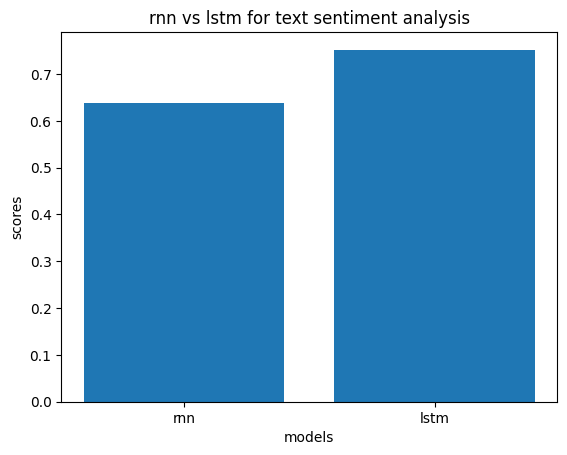

In [11]:
import matplotlib.pyplot as plt

models=["rnn", "lstm"]
rnn_ac=acc
scores=[rnn_ac, lstm_acc]
plt.bar(models, scores)
plt.title("rnn vs lstm for text sentiment analysis")
plt.xlabel("models")
plt.ylabel("scores")
plt.show()